# 

In [5]:
import os
os.chdir("..")  # go up one level

In [6]:
import glob
import json
import pandas as pd
import re

paths = glob.glob("calibrationData/**/metadata.json", recursive=True)

exclude = ["old", "additional"]

filtered_paths = [path for path in paths if not any(exclude_item in path for exclude_item in exclude)]

rows = []

for path in filtered_paths:
    try:
        with open(path, "r") as f:
            data = json.load(f)
        
        data["folder"] = path.rsplit("/", 1)[0]  # keep folder info
        rows.append(data)
        
    except Exception as e:
        print(f"Error reading {path}: {e}")

df = pd.DataFrame(rows)
df["dataset"] = df["dataset"].fillna("gsm8k")
df["dataset"] = df["dataset"].replace({"cais/mmlu": "mmlu"})


def get_model_size(model_name):
    match = re.search(r"([\d.]+)\s*B", model_name)
    return float(match.group(1)) if match else None

df["model_size"] = df["model"].apply(get_model_size)
    
summary = df.set_index( ["model", "dataset"]).sort_index()

In [7]:
summary

dataset_config  batch_size  thinking        timestamp  \
model           dataset                                                         
Qwen/Qwen3-0.6B ai2_arc  ARC-Challenge          32     False  20260622_173051   
                gsm8k              NaN          48     False  20260630_170343   
                mmlu               NaN          48     False  20260622_152503   
Qwen/Qwen3-1.7B ai2_arc  ARC-Challenge          64     False  20260622_173148   
                gsm8k              NaN          32     False  20260630_170635   
                mmlu               NaN          32     False  20260622_154426   
Qwen/Qwen3-14B  ai2_arc  ARC-Challenge          48     False  20260622_174328   
                gsm8k              NaN          48     False  20260630_173130   
                mmlu               NaN          16     False  20260621_190850   
Qwen/Qwen3-32B  ai2_arc  ARC-Challenge          48     False  20260622_180623   
                gsm8k              NaN          32     False  20260630_173549   
                mmlu               NaN          16     False  20260630_164310   
Qwen/Qwen3-4B   ai2_arc  ARC-Challenge          64     False  20260622_173257   
                gsm8k              NaN          16     False  20260630_171037   
                mmlu               NaN          16     False  20260622_155853   
Qwen/Qwen3-8B   ai2_arc  ARC-Challenge          20     False  20260622_173542   
                gsm8k              NaN          32     False  20260626_152128   
                mmlu               NaN          32     False  20260621_193541   

                        device max_samples  \
model           dataset                      
Qwen/Qwen3-0.6B ai2_arc   cuda        None   
                gsm8k     cuda        None   
                mmlu      cuda        None   
Qwen/Qwen3-1.7B ai2_arc   cuda        None   
                gsm8k     cuda        None   
                mmlu      cuda        None   
Qwen/Qwen3-14B  ai2_arc   cuda        None   
                gsm8k     cuda        None   
                mmlu      cuda        None   
Qwen/Qwen3-32B  ai2_arc   cuda        None   
                gsm8k     cuda        None   
                mmlu      cuda        None   
Qwen/Qwen3-4B   ai2_arc   cuda        None   
                gsm8k     cuda        None   
                mmlu      cuda        None   
Qwen/Qwen3-8B   ai2_arc   cuda        None   
                gsm8k     cuda        None   
                mmlu      cuda        None   

                                                             system_prompt  \
model           dataset                                                      
Qwen/Qwen3-0.6B ai2_arc  Answer the following multiple-choice question....   
                gsm8k    You are a direct mathematical calculator.\n\nI...   
                mmlu      Your task is to answer multiple-choice questi...   
Qwen/Qwen3-1.7B ai2_arc  Answer the following multiple-choice question....   
                gsm8k    You are a direct mathematical calculator.\n\nI...   
                mmlu      Your task is to answer multiple-choice questi...   
Qwen/Qwen3-14B  ai2_arc  Answer the following multiple-choice question....   
                gsm8k    You are a direct mathematical calculator.\n\nI...   
                mmlu      Your task is to answer multiple-choice questi...   
Qwen/Qwen3-32B  ai2_arc  Answer the following multiple-choice question....   
                gsm8k    You are a direct mathematical calculator.\n\nI...   
                mmlu      Your task is to answer multiple-choice questi...   
Qwen/Qwen3-4B   ai2_arc  Answer the following multiple-choice question....   
                gsm8k    You are a direct mathematical calculator.\n\nI...   
                mmlu      Your task is to answer multiple-choice questi...   
Qwen/Qwen3-8B   ai2_arc  Answer the following multiple-choice question....   
                gsm8k    You are a direct mathematical calculator.\n\nI...   


In [8]:
import numpy as np
import re

def preprocess_gsm8k(df):
    df["log_conf"] = df["logprobs"].apply(lambda xs: np.exp(sum(xs)/len(xs)) if xs else 0.5)
    
    
    def extract_answer(text):
        match = re.search(r"####\s*(\-?\d+\.?\d*)", text)
        return float(match.group(1)) if match else None
    
    df["full_answer"] = df["answer"]
    df["answer"] = df["full_answer"].apply(extract_answer)
    
    def parse_prediction(pred):
        match = re.findall(r"-?\d+\.?\d*", str(pred))
        return float(match[-1]) if match else None
    
    df["prediction"] = df["prediction"].apply(parse_prediction)
    df["correct"] = df["answer"] == df["prediction"]

In [9]:
def preprocess_ai2_arc(df):
    df["correct"] = df["answer"] == df["prediction"]
    
    def get_log_conf(row):
        labels = row["labels"]
        probs = row["label_probs"]
        prediction = row["prediction"][0]
    
        try:
            idx = labels.index(prediction)
            return probs[idx]
        except:
            print(labels, probs, prediction)
        
    df["log_conf"] = df.apply(get_log_conf, axis=1)

In [10]:
def preprocess_mmlu(df):
    df["correct"] = df["answer"] == df["prediction"]
    
    def get_log_conf(row):
        labels = row["labels"]
        probs = row["label_probs"]
        prediction = row["prediction"][0]
    
        try:
            idx = labels.index(prediction)
            return probs[idx]
        except:
            print(labels, probs, prediction)
        
    df["log_conf"] = df.apply(get_log_conf, axis=1)

In [11]:
import numpy as np
import pandas as pd

def process_df(df):
    records = []
    datasets = df.index.get_level_values("dataset").unique()

    for dataset in datasets:
        files = df.xs(dataset, level="dataset")

        for model, row in files.iterrows():
            file = f"{row['folder']}/outputs.jsonl"
            output_file = pd.read_json(file, lines=True)

            if dataset == "gsm8k":
                preprocess_gsm8k(output_file)
            elif dataset == "ai2_arc":
                preprocess_ai2_arc(output_file)
            elif dataset == "mmlu":
                preprocess_mmlu(output_file)
            else:
                raise ValueError(f"Unknown dataset: {dataset}")

            rec = {
                "model": model,
                "dataset": dataset,
                "model_size": row["model_size"],
                "acc": output_file["correct"].mean(),
                "num_samples": len(output_file),
            }

            for method in ["verb", "log"]:
                conf_col = f"{method}_conf"
                mask = output_file[conf_col].notna()

                y_true = output_file.loc[mask, "correct"].to_numpy()
                y_conf = output_file.loc[mask, conf_col].to_numpy()

                # calibration bins (equal-frequency / deciles)
                if len(y_conf) == 0:
                    rec[f"{method}_bin_conf"] = [np.nan] * 10
                    rec[f"{method}_bin_acc"] = [np.nan] * 10
                else:
                    cal_df = pd.DataFrame({
                        "conf": y_conf,
                        "correct": y_true,
                    }).sort_values("conf").reset_index(drop=True)

                    # qcut on rank index → stable 10 equal-frequency bins
                    cal_df["pool"] = pd.qcut(
                        np.arange(len(cal_df)),
                        q=10,
                        labels=False
                    )

                    pool_stats = (
                        cal_df.groupby("pool")
                        .agg(
                            avg_conf=("conf", "mean"),
                            avg_acc=("correct", "mean"),
                        )
                        .reindex(range(10))  # ensure all bins exist
                    )

                    rec[f"{method}_bin_conf"] = pool_stats["avg_conf"].tolist()
                    rec[f"{method}_bin_acc"] = pool_stats["avg_acc"].tolist()

            records.append(rec)

    summary = pd.DataFrame.from_records(records).set_index(["model", "dataset"])
    return summary


results = process_df(summary)


['A', 'B', 'C', 'D'] [0.006518247071653001, 0.008369594812393001, 0.017718432471156002, 0.9673936367034911] I


In [12]:
results.explode(["verb_bin_conf", "verb_bin_acc", "log_bin_conf", "log_bin_acc"]).head()

model_size      acc  num_samples verb_bin_conf  \
model           dataset                                                   
Qwen/Qwen3-0.6B ai2_arc         0.6  0.59727         1172      0.930085   
                ai2_arc         0.6  0.59727         1172          0.99   
                ai2_arc         0.6  0.59727         1172          0.99   
                ai2_arc         0.6  0.59727         1172          0.99   
                ai2_arc         0.6  0.59727         1172          0.99   

                        verb_bin_acc log_bin_conf log_bin_acc  
model           dataset                                        
Qwen/Qwen3-0.6B ai2_arc      0.59322      0.48987    0.466102  
                ai2_arc     0.547009     0.670105    0.367521  
                ai2_arc     0.555556     0.808364    0.435897  
                ai2_arc      0.57265     0.917087    0.512821  
                ai2_arc     0.632479     0.968846    0.529915

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_calibration(df, method="verb", dataset=None):
    data = df.reset_index()

    # Optional filtering by dataset
    if dataset is not None:
        data = data[data["dataset"] == dataset]
    else:
        # Fix: Added 'raise' to properly throw the exception
        raise ValueError("Please specify a dataset to plot calibration curves.")

    data = data.explode([f"{method}_bin_conf", f"{method}_bin_acc"])
    
    # Ensure model_size is numeric so the continuous colormap doesn't break
    data["model_size"] = pd.to_numeric(data["model_size"])

    fig, ax = plt.subplots(figsize=(7, 5))

    # 1. Define colormap and normalize based on the model_size range
    cmap = "flare"
    norm = plt.Normalize(data["model_size"].min(), data["model_size"].max())

    # 2. Plot the data (Fix: Removed trailing 'co')
    sns.lineplot(
        data=data, 
        x=f"{method}_bin_conf", 
        y=f"{method}_bin_acc", 
        hue="model_size", 
        markers="o", 
        legend=False, 
        palette=cmap, 
        hue_norm=norm,
        ax=ax
    )
    
    # 3. Create the ScalarMappable and add the colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Model Size')

    # 4. Standard formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_title(f"Calibration: {dataset} ({method})") # Added a dynamic title
    
    plt.tight_layout()
    plt.show()

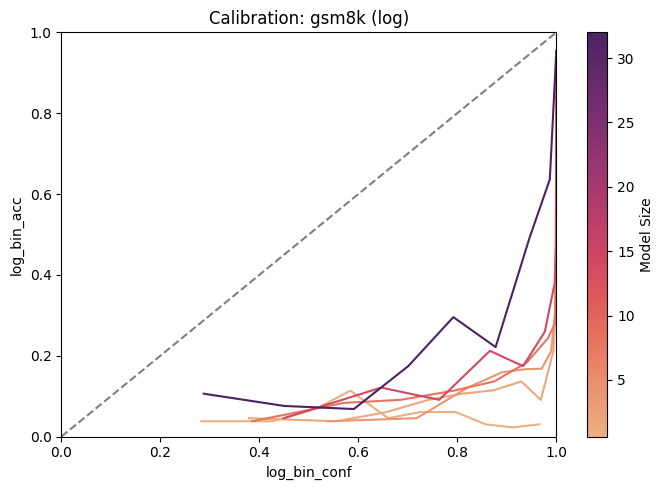

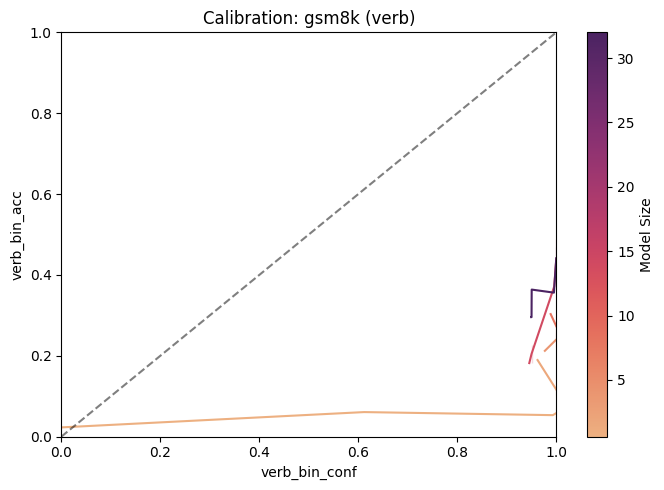

In [14]:
plot_calibration(results, method="log", dataset="gsm8k")
plot_calibration(results, method="verb", dataset="gsm8k")

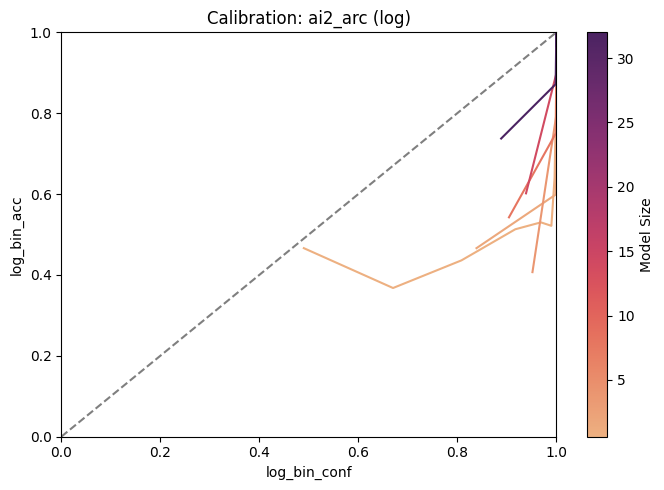

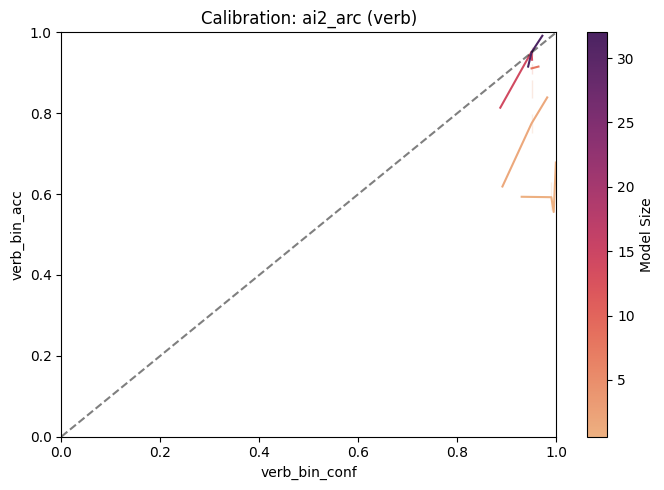

In [18]:

plot_calibration(results, method="log", dataset="ai2_arc")
plot_calibration(results, method="verb", dataset="ai2_arc")

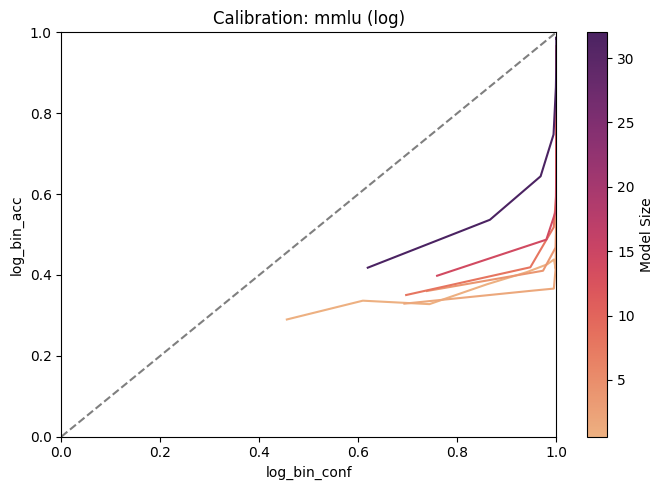

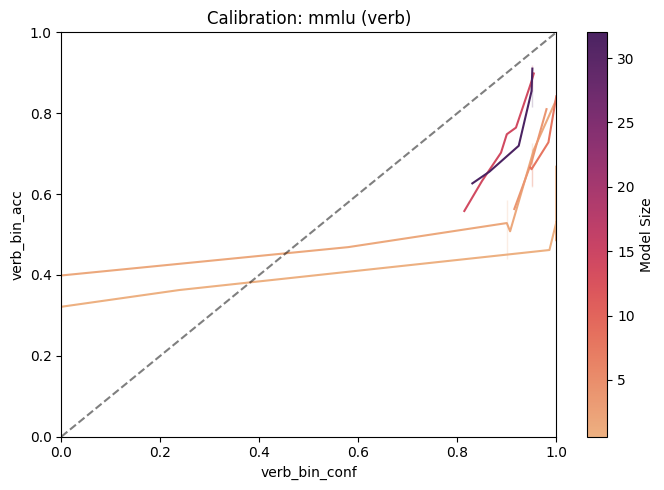

In [25]:

plot_calibration(results, method="log", dataset="mmlu")
plot_calibration(results, method="verb", dataset="mmlu")